In [135]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
import numpy as np
import seaborn as sns
 

In [136]:
games_df= pd.read_csv('/datasets/games.csv')

In [137]:
games_df.columns= games_df.columns.str.lower()

In [138]:
games_df.sample(20)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
11581,Lost Dimension,PSV,2014.0,Role-Playing,0.03,0.01,0.02,0.02,72.0,8.3,T
4293,Country Dance 2,Wii,2011.0,Misc,0.43,0.00,0.00,0.03,NaN,tbd,E10+
5036,Moto Racer World Tour,PS,2000.0,Racing,0.21,0.14,0.00,0.02,NaN,NaN,NaN
2327,Classic NES Series: The Legend of Zelda,GBA,2004.0,Adventure,0.46,0.17,0.24,0.02,84.0,8.6,E
2215,White Knight Chronicles: International Edition,PS3,2008.0,Role-Playing,0.33,0.16,0.36,0.08,64.0,7.5,T
12814,BattleBots: Beyond the BattleBox,GBA,2002.0,Action,0.04,0.01,0.00,0.00,53.0,tbd,E
13217,Dream Salon,Wii,2009.0,Misc,0.05,0.00,0.00,0.00,NaN,tbd,E
14144,Astrology DS,DS,2009.0,Misc,0.03,0.00,0.00,0.00,NaN,NaN,NaN
8166,Shaun White Skateboarding,Wii,2010.0,Sports,0.13,0.03,0.00,0.01,59.0,tbd,E10+
852,Super Street Fighter II,SNES,1993.0,Fighting,0.52,0.16,1.29,0.03,NaN,NaN,NaN


In [139]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Has comenzado muy bien. La carga del dataset y la conversión de las columnas a minúsculas es un excelente paso inicial. Esto asegura consistencia y evita posibles errores a lo largo del análisis, especialmente cuando se trabaja con nombres de columnas. La visualización de una muestra de los datos con `.sample(20)` es una buena práctica para verificar la estructura de tu dataset y asegurarte de que los datos están correctamente formateados. ¡Sigue así con esta atención al detalle! 💪
</div>



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El uso de `.info()` es crucial en esta etapa, ya que te proporciona una visión completa del tamaño del dataset, tipos de datos y posibles valores nulos. Es un paso importante para empezar a planificar la limpieza de datos y cualquier transformación necesaria más adelante en el análisis. ¡Buen inicio en la gestión de tu dataset! 📊
</div>


Cambiamos los datos de year_of_release y user_score

In [140]:
games_df['year_of_release'] = games_df['year_of_release'].astype('Int64')
games_df['user_score'] = pd.to_numeric(games_df['user_score'], errors='coerce')
games_df.info()
games_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


los datos de las columnas 'year_of_release' fueron cambiados de float64 a int64 ya que solo importa el año en el que el juego salio a la venta y no se toma en cuenta si salio a la mitad del año por lo que es mejor trabajarlos como enteros. Los datos de la columna 'user_score' fueron cambiados de object a float64 ya que al ser una calificacion del 1 al 10 y con decimales, se deben cambiar a float64 y algunos datos estaban como 'tbd' los cuales fueron cambiados a NaN.

In [141]:
games_df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Excelente trabajo al convertir los tipos de datos de las columnas `year_of_release` y `user_score`. Cambiar `year_of_release` de `float64` a `Int64` es una decisión lógica, ya que solo te interesa el año de lanzamiento sin decimales. Esto no solo mejora la claridad de los datos, sino que también optimiza la eficiencia de tu análisis. Además, convertir `user_score` de `object` a `float64` te permite trabajar correctamente con los datos numéricos y manejar los decimales de las puntuaciones de usuarios, lo cual es crucial para los análisis posteriores. ¡Bien hecho! 🏆
</div>



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
El uso de `.info()` y `.head()` es una excelente práctica para validar que los cambios en los tipos de datos se hayan aplicado correctamente. Esto te asegura que los datos están en el formato esperado antes de avanzar con el análisis. También, el comando `.isna().sum()` te da una visión clara de los valores faltantes, lo que es clave para tomar decisiones informadas sobre la limpieza de datos. ¡Sigue así, estás manejando el flujo de trabajo de manera eficiente! 💪
</div>


#### RELLENAMOS LOS DATOS DE LAS COLUMNAS CRITIC_SCORE, USER_SCORE Y RATING.

In [142]:
games_df['critic_score'].fillna(games_df['critic_score'].mean(), inplace=True)
games_df['user_score'].fillna(games_df['user_score'].mean(), inplace=True)
games_df['rating'].fillna('no rating', inplace=True)
games_df.dropna(inplace=True)
games_df.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.000000,8.000000,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,68.967679,7.125046,no rating
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.000000,8.300000,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.000000,8.000000,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,68.967679,7.125046,no rating
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,68.967679,7.125046,no rating
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.000000,8.500000,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.000000,6.600000,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.000000,8.400000,E
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,68.967679,7.125046,no rating


In [143]:
games_df.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

In [144]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  float64
 9   user_score       16444 non-null  float64
 10  rating           16444 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB


Eliminamos 269 de 16714 ya que haban valores ausentes en la columna 'year_of_release' y dado que 269 s un numero pequeño para la cantidad de datos que tenemos considero que no es problema simplemente eliminarlos para facilitar el analisis de datos, tambien eliminamos 2 de 16714 por valores ausentes en la columna 'name' y 2 de 16714 por la columna 'genre' ya que 2 filas son practicamente insignificantes. en cuanto a las columnas de 'critic_score' y 'user_score' nos encontramos con 8578 y 9125 datos ausentes respectivamente por lo que en este caso deshacerce de columnas si afectaria el analisis entonces rellenamos los datos ausentes de esas columnas con el critic score promedio y el user score promedio y en cuanto a la columna 'rating' encontramos 6766 datos ausentes por lo que los llenamos con 'no rating' ya que si lo llenaramos con la moda estariamos alterando los datos que tenemos. En cuanto a los datos con 'tbd' fueron remplazados ya que aun no han sido determidados. 

In [145]:
print(games_df.duplicated().sum())

0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
Has manejado correctamente el tratamiento de los valores ausentes en las columnas `critic_score`, `user_score` y `rating`. Utilizar la media para rellenar los valores faltantes en las puntuaciones es una buena opción en este caso, ya que permite preservar la mayor cantidad de datos posible sin introducir sesgos significativos. Además, rellenar los valores ausentes en `rating` con 'no rating' es una solución razonable, ya que evita el uso de la moda, que podría distorsionar los resultados. Este enfoque asegura que puedas avanzar con el análisis sin perder información valiosa. ¡Buen trabajo gestionando los valores ausentes de forma efectiva! 🎯
</div>



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
La decisión de eliminar 269 filas con valores ausentes en `year_of_release` es comprensible dado que representan una pequeña proporción del dataset. De manera similar, eliminar las filas con datos faltantes en `name` y `genre` es adecuado, ya que son datos cruciales para el análisis. Además, tu uso de `.duplicated()` es una excelente práctica para verificar la existencia de duplicados, asegurando así que el dataset esté limpio y listo para su análisis. ¡Buen manejo de la limpieza de datos! 💡
</div>


#### AGREGAMOS UNA COLUMNA QUE CONTENGA EL TOTAL DE VENTAS PARA CADA JUEGO EN MILLONES DE DOLARES.

In [146]:
games_df['total_sales']= games_df['na_sales'] + games_df['eu_sales'] + games_df['jp_sales'] + games_df['other_sales']
games_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.000000,8.000000,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,68.967679,7.125046,no rating,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.000000,8.300000,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.000000,8.000000,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,68.967679,7.125046,no rating,31.38


AGRUPAMOS POR AÑO Y USAMOS VALUE_COUNTS() PARA OBTENER CUANTOS JUEGOS FUERON VENDIDOS POR AÑO

In [147]:
yearly_games_released = games_df['year_of_release'].value_counts().sort_index()
print(yearly_games_released)

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64


#### AHORA LO PRESENTAMOS EN UN GRAFICO DE BARRAS

<AxesSubplot:xlabel='year_of_release'>

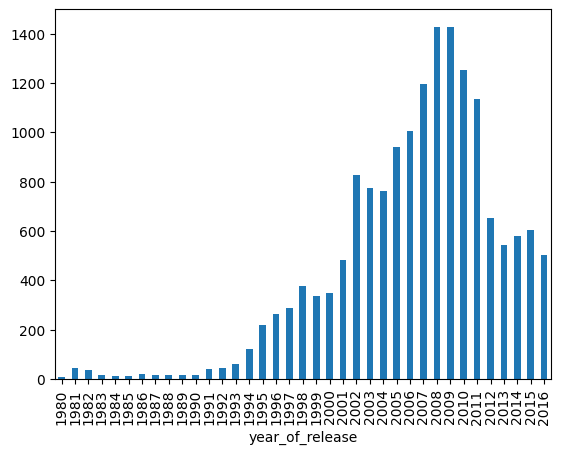

In [148]:
games_df.groupby('year_of_release')['name'].count().plot(kind='bar')

podemos observar como la cantidad de juegos lanzados por año va aumentando de 1980 a los años 2010s aprox y vuelve a haber 
una caida del 2012 al 2016.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Has realizado un excelente trabajo al agregar la columna `total_sales` sumando las ventas de diferentes regiones. Este es un paso crucial para obtener una visión general de los ingresos globales de cada juego y permite realizar análisis más profundos. Además, la agrupación por año utilizando `value_counts()` para analizar cuántos juegos fueron lanzados anualmente es una estrategia efectiva para identificar tendencias en la industria de los videojuegos.

El gráfico de barras que creaste proporciona una visualización clara del aumento y la posterior caída en el número de lanzamientos de juegos a lo largo del tiempo. ¡Sigue utilizando estos enfoques visuales y numéricos para profundizar en tu análisis, lo estás haciendo muy bien! 📊👏
</div>


CREAMOS PLATFORM_SALES PARA VER LAS VENTAS TOTALES POR PLATAFORMA POR AÑO Y DESPUES CREAMOS TOTAL_SALES_BY_PLATFORM PARA OBTENER LAS VENTAS TOTALES POR PLATAFORMA

In [149]:
platform_sales = games_df.groupby(['platform', 'year_of_release'])['total_sales'].sum().sort_values(ascending=False).reset_index()
total_sales_by_platform = games_df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales.head(20))
print(total_sales_by_platform.head(20))



   platform  year_of_release  total_sales
0       PS2             2004       211.81
1       Wii             2009       206.97
2       PS2             2002       205.38
3       PS2             2003       184.31
4       Wii             2008       171.32
5      X360             2010       170.03
6        PS             1998       169.49
7       PS2             2001       166.43
8       PS2             2005       160.66
9       PS3             2011       156.78
10      Wii             2007       152.77
11       DS             2007       146.94
12       DS             2008       145.31
13       PS             1999       144.53
14     X360             2011       143.84
15      PS3             2010       142.17
16      Wii             2006       137.15
17       PS             1997       136.17
18     X360             2008       135.26
19      PS3             2009       130.93
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.

#### A CONTINUACION TOMAMOS LAS 10 PLATAFORMAS CON EL NUMERO DE VENTAS MAS ALTO Y DESPUES GRAFICAMOS ESAS 10.

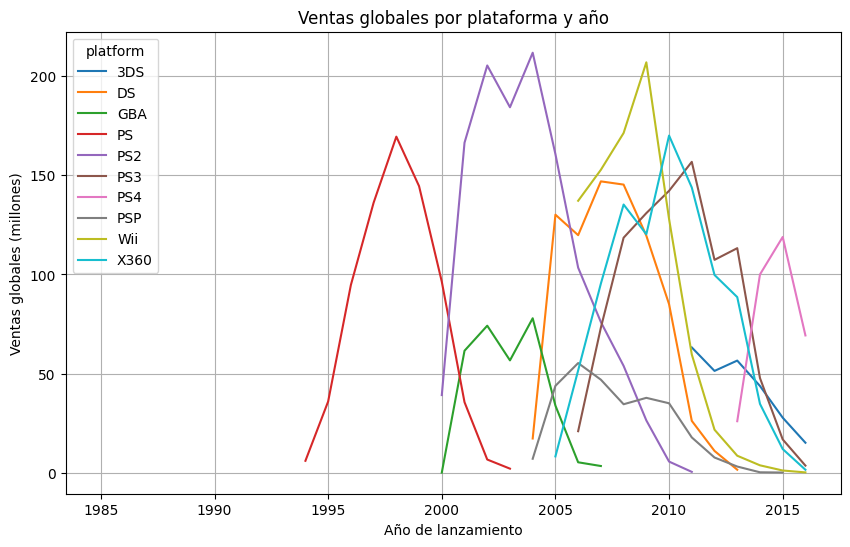

In [150]:
top_platforms = total_sales_by_platform.head(10).index

df_top_platforms = games_df[games_df['platform'].isin(top_platforms)]


sales_by_year_platform = df_top_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

sales_by_year_platform.plot(kind='line', figsize=(10,6))
plt.title('Ventas globales por plataforma y año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas globales (millones)')
plt.grid(True)
plt.show()

ahora con este grafico podemos ver en que momento cada plataforma tuvo su pico de ventas y cuando el punto minimo como podemos observar las ventas de 
3DS: Comienzan alrededor del 2011 y van en bajada hasta el 2016.

DS: Comienzan alrededor del 2004 tiene su pico alrededor del 2008 y va de bajada hasta el 2013.

GBA: Comienzan alrededor del 2000 tiene su pico alrededor del 2004 y va de bajada hasta el 2007.

PS: Comienzan alrededor del 1994 tiene su pico alrededor del 1998 y va de bajada hasta el 2003.

PS2: Comienzan alrededor del 2000 tiene su pico alrededor del 2004 y va de bajada hasta el 2011, llego a superar los 200M de ventas en su año pico.

PS3: Comienzan alrededor del 2006 tiene su pico alrededor del 2012 y va de bajada hasta el 2016.

PS4: Comienzan alrededor del 2013 tiene su pico alrededor del 2015 y va de bajada hasta el 2016 en donde aun se ven unos 70M de ventas en ese año, a diferencia de otras que simplemente dejaron de tener ventas.

PSP: Comienzan alrededor del 2004 tiene su pico alrededor del 2006 y va de bajada hasta el 2014, aunque en su año pico solo alcanzo aproximadamente 60M de ventas, el mas bajo entre las otras plataformas.

Wii: Comienzan alrededor del 2006 tiene su pico alrededor del 2009 y va de bajada hasta el 2013, tambien llego a alcanzar los 200M de ventas en su año pico.

X360: Comienzan alrededor del 2005 tiene su pico alrededor del 2010 y va de bajada hasta el 2016.

#### AHORA HACEMOS UN DIAGRAMA DE CAJA PERO SOLO CON EL TOP 10 DE PLATAFORMAS

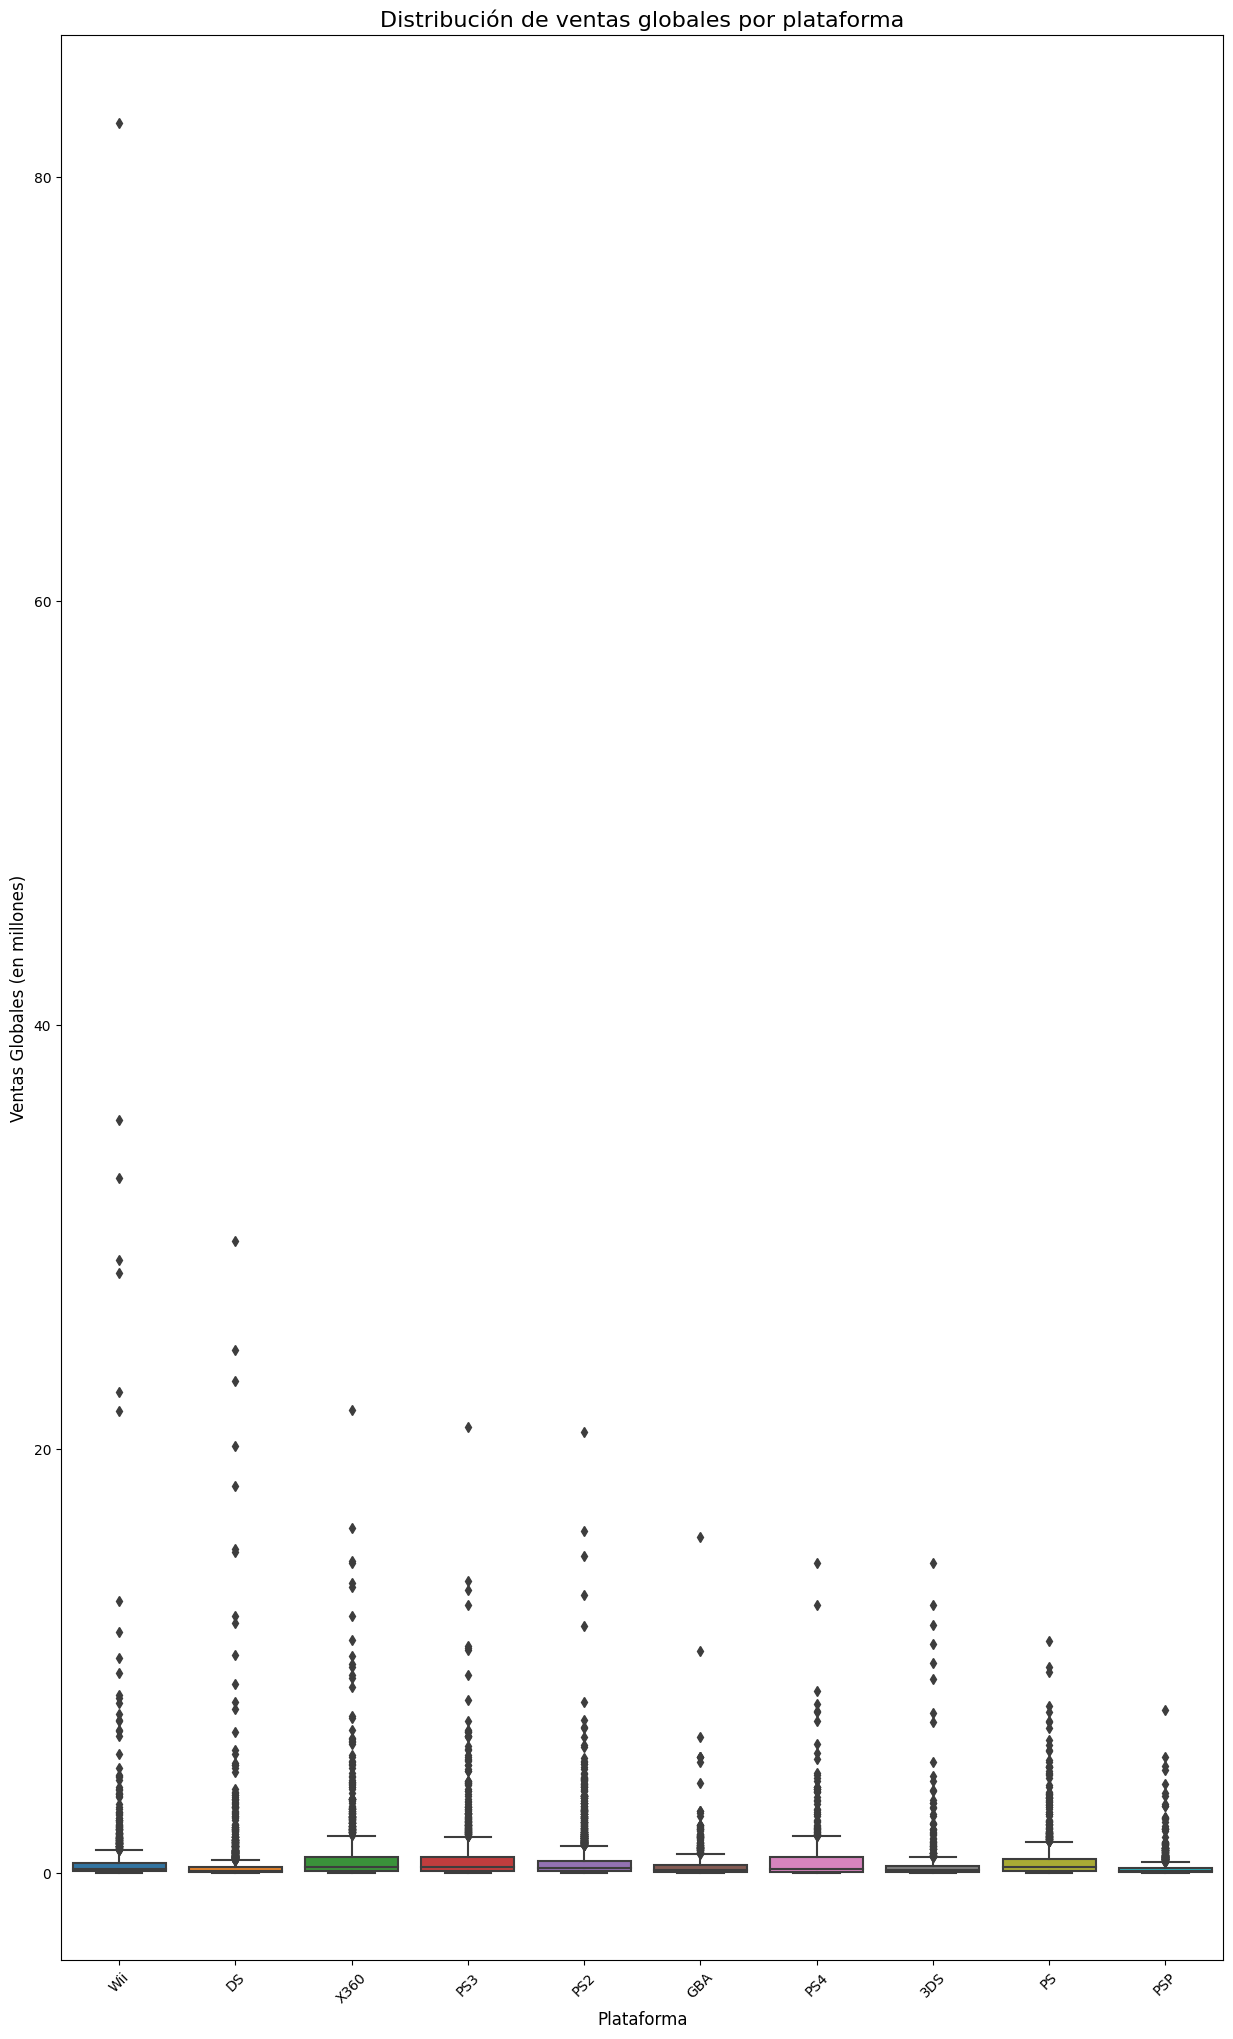

In [151]:
plt.figure(figsize=(15, 25))


sns.boxplot(x='platform', y='total_sales', data=df_top_platforms)


plt.title('Distribución de ventas globales por plataforma', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Globales (en millones)', fontsize=12)


plt.xticks(rotation=45)


plt.show()

Podemos observar que en promedio los juegos apenas logran tener un millon de dolares en ventas a traves de las plataformas a pesar de que algunas plataformas lograron superar 200 millones de dolares en ventas anuales esto se debe a que hay una gran cantidad de valores atipicos que son los juegos que realmente generaron ventas como por ejemplo la plataforma Wii tuvo un solo juego(Wii sports) que ese solo genero 82 millones de dolares en ventas y otra gran cantidad de juegos tuvieron mas de 10 millones de dolares en ventas, ahora PS2, PS3, Wii y X360 son las 4 plataformas con mayor numero de ventas totales y cada una de estas plataformas estuvieron aproximadamente 10 años hasta que dejaron de tener ventas mientras que 3DS, PSP, GBA Y PS4 fueron las 4 con menor numero de ventas totales. se puede observar que 3DS estuvo aproximadamente 5 años, GBA unos 6 años, PS4 con aproximadamente 4 años y solo PSP estuvo alrededro de 10 años aunque fue la que menos logro acumular ventas de las top 10 plataformas.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Has realizado un trabajo impresionante al analizar las ventas totales por plataforma a lo largo del tiempo. El agrupamiento por año y plataforma proporciona una visión clara de cómo las diferentes plataformas han evolucionado en el mercado. La gráfica de líneas para visualizar las ventas globales por plataforma y año es una excelente elección, ya que permite identificar los picos y declives en las ventas de cada consola de manera cronológica.
Tu análisis de los valores atípicos, como el caso de Wii Sports en la Wii, muestra que entiendes bien la importancia de los outliers en el análisis de datos. También has hecho un buen trabajo al destacar cómo algunas plataformas, como PS2 y X360, dominaron el mercado durante años.
En resumen, tu análisis es exhaustivo y las visualizaciones son claras y bien explicadas. ¡Continúa utilizando estas herramientas visuales y analíticas para profundizar aún más en el mercado de videojuegos! 🚀📈
</div>


#### AHORA CREAREMOS GRAFICOS DEDISPERSION Y CALCULAREMOS LA CORRELACION ENTRE LAS VENTAS DE LA PLATAFORMA PS3 Y LAS RESEÑAS DE USER SCORE Y DE CRITIC SCORE.

In [152]:
PS3_data = games_df[games_df['platform'] == 'PS3']


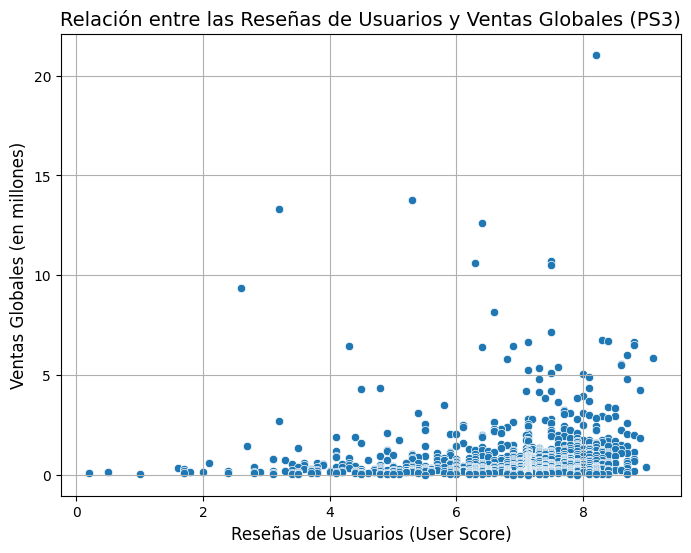

In [153]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='user_score', y='total_sales', data=PS3_data)
plt.title('Relación entre las Reseñas de Usuarios y Ventas Globales (PS3)', fontsize=14)
plt.xlabel('Reseñas de Usuarios (User Score)', fontsize=12)
plt.ylabel('Ventas Globales (en millones)', fontsize=12)
plt.grid(True)
plt.show()


In [154]:
user_score_correlation = PS3_data['user_score'].corr(PS3_data['total_sales'])
print(f'Correlación entre User Score y Ventas Totales: {user_score_correlation}')


Correlación entre User Score y Ventas Totales: 0.0800612780167658


Ahora en el grafico de dispersion podemos observar que hay una leve correlacion positiva entre las ventas y el user score, despues calculamos la correlacion y podemos ver que la correlacion positiva es solo de 0.0800612 por lo que aunque si bien lo ideal es que los usuarios disfruten el juego y le den un score alto, este score no impactara las ventas significativamente a diferencia del score de los criticos como podemos observar a continuacion.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Excelente trabajo visualizando la relación entre las reseñas de los usuarios y las ventas globales de la PS3! El uso de un gráfico de dispersión es una elección adecuada para detectar la correlación entre dos variables continuas como `user_score` y `total_sales`. La inclusión de un cálculo de correlación es clave para cuantificar esta relación, y es muy útil que hayas mostrado el resultado con una correlación positiva leve. Este tipo de análisis es crucial para entender si las opiniones de los usuarios están relacionadas con las ventas.
El formato de tu gráfico es claro, lo que facilita su interpretación. Continúa con este enfoque en futuros análisis, ya que las visualizaciones junto con el cálculo de correlación ofrecen una perspectiva tanto cualitativa como cuantitativa.  👏📊
</div>


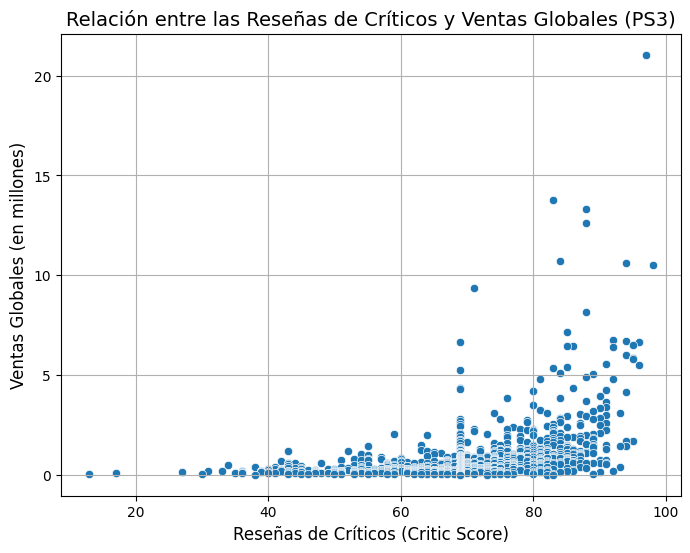

In [155]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='critic_score', y='total_sales', data=PS3_data)
plt.title('Relación entre las Reseñas de Críticos y Ventas Globales (PS3)', fontsize=14)
plt.xlabel('Reseñas de Críticos (Critic Score)', fontsize=12)
plt.ylabel('Ventas Globales (en millones)', fontsize=12)
plt.grid(True)
plt.show()


In [156]:
critic_score_correlation = PS3_data['critic_score'].corr(PS3_data['total_sales'])
print(f'Correlación entre Critic Score y Ventas Totales: {critic_score_correlation}')


Correlación entre Critic Score y Ventas Totales: 0.4196588601333411


Ahora hicimos lo mismo pero utilizando el score de criticos y de primera podemos observar en el grafico de dispersion que la correlacion es mas clara, entre mas alto sea el score, mas alto sera el numero de ventas. Calculamos la correlacion y encontramos que hay una correlacion de 0.41965 a diferencia de la correlacion de user score podemos concluir que el score de los criticos tendra un impacto significativo en el numero de ventas.

In [157]:
games_on_multiple_platforms = games_df.groupby('name')['platform'].nunique()
multiple_platform_games = games_on_multiple_platforms[games_on_multiple_platforms > 1].index
df_multiple_platform_games = games_df[games_df['name'].isin(multiple_platform_games)]


In [158]:
sales_comparison = df_multiple_platform_games.groupby(['name', 'platform'])['total_sales'].sum().unstack()
sales_comparison.head()


platform,2600,3DS,DC,DS,GB,GBA,GC,GEN,N64,NES,...,PSP,PSV,SAT,SNES,WS,Wii,WiiU,X360,XB,XOne
name,,,,,,,,,,,,,,,,,,,,,
Frozen: Olaf's Quest,NaN,0.59,NaN,0.51,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
007: Quantum of Solace,NaN,NaN,NaN,0.13,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.65,NaN,1.48,NaN,NaN
007: The World is not Enough,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.56,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11eyes: CrossOver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.02,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN,NaN
18 Wheeler: American Pro Trucker,NaN,NaN,NaN,NaN,NaN,NaN,0.11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


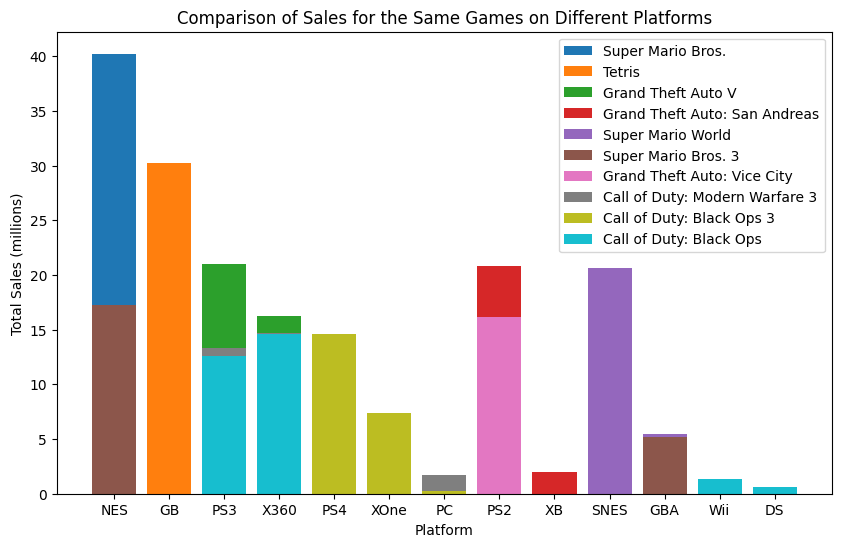

In [159]:
subset_games = df_multiple_platform_games['name'].unique()[:10]
df_subset = df_multiple_platform_games[df_multiple_platform_games['name'].isin(subset_games)]
plt.figure(figsize=(10,6))
for game in subset_games:
    game_data = df_subset[df_subset['name'] == game]
    plt.bar(game_data['platform'], game_data['total_sales'], label=game)

plt.xlabel('Platform')
plt.ylabel('Total Sales (millions)')
plt.title('Comparison of Sales for the Same Games on Different Platforms')
plt.legend(loc='upper right')
plt.show()


Con este grafico podemos comparar que las ventas de jalgunos juegos en diferentes plataformas, como por ejemplo Call of Duty: Black Ops 3 se vendio mas de el doble en PS4 que en XOne pero podemos notar que para el Call of Duty: Black Ops X360 supero a PS3 en ventas de ese juego. Se puede observar que NES es la plataforma con mas ventas para Super Mario Bros. y Super Mario Bros. 3.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
Has realizado un análisis sólido al utilizar gráficos de dispersión para visualizar la relación entre el `critic_score` y las ventas totales de la plataforma PS3. Es evidente que entendiste la importancia de las reseñas de críticos, ya que la correlación que encontraste (0.41965) muestra que las calificaciones de los críticos tienen un impacto significativo en las ventas.
 El gráfico de barras permite una comparación clara entre plataformas como PS4 y XOne o entre NES y otras consolas. Destacar diferencias como las mayores ventas de Call of Duty: Black Ops 3 en PS4 frente a XOne, y cómo X360 superó a PS3, proporciona una visión valiosa del comportamiento del mercado y preferencias de los jugadores en distintas consolas. ¡Sigue adelante con este enfoque analítico y visual, estás desarrollando un análisis completo y muy claro! 🚀🎮📊
</div>


In [160]:
genre_sales = games_df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(genre_sales)


genre
Action          1716.52
Sports          1309.67
Shooter         1041.36
Role-Playing     931.08
Platform         825.55
Misc             790.29
Racing           723.49
Fighting         442.66
Simulation       387.96
Puzzle           239.89
Adventure        233.33
Strategy         172.57
Name: total_sales, dtype: float64


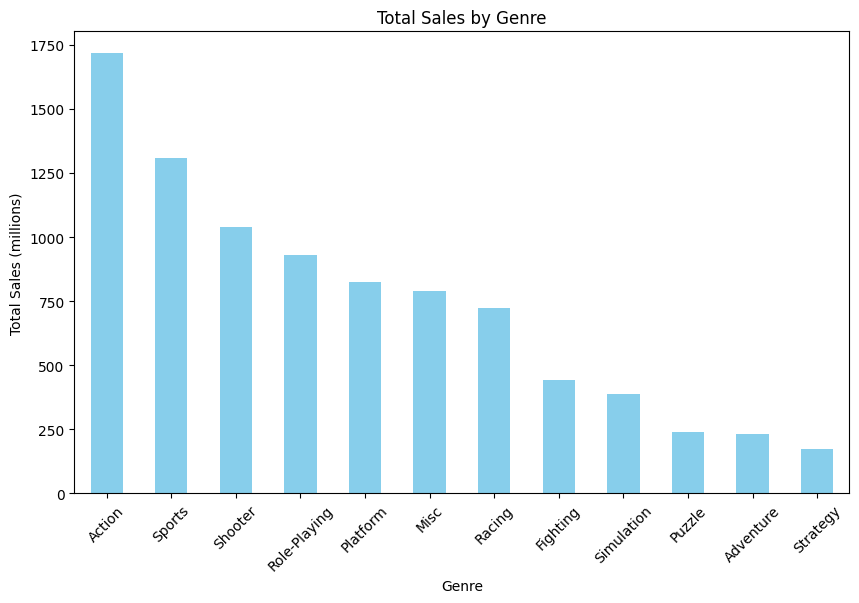

In [161]:
plt.figure(figsize=(10,6))
genre_sales.plot(kind='bar', color='skyblue')
plt.xlabel('Genre')
plt.ylabel('Total Sales (millions)')
plt.title('Total Sales by Genre')
plt.xticks(rotation=45)
plt.show()


Ahora acomodamos los juegos por genero y sus ventas totales y podemos encontrar cuales generos suelen tener mayor numero de ventas y cuales tener un menor numero de ventas.
los juegos de accion lideran con mas de 1700 millones de dolares en ventas seguido por deportes y juegos de shooter con aproximadamente 1250M y 1100M. Mientras que los generos que generaron menor numero de ventas fueron juegos de estrategia, aventura y puzzle de los cuales ninguno logro cruzar la marca de 300M de dolares en ventas.

genre
Platform        0.940262
Shooter         0.803519
Role-Playing    0.628683
Racing          0.590122
Sports          0.567940
Fighting        0.528865
Action          0.519057
Misc            0.459204
Simulation      0.452695
Puzzle          0.421599
Strategy        0.256419
Adventure       0.180456
Name: total_sales, dtype: float64


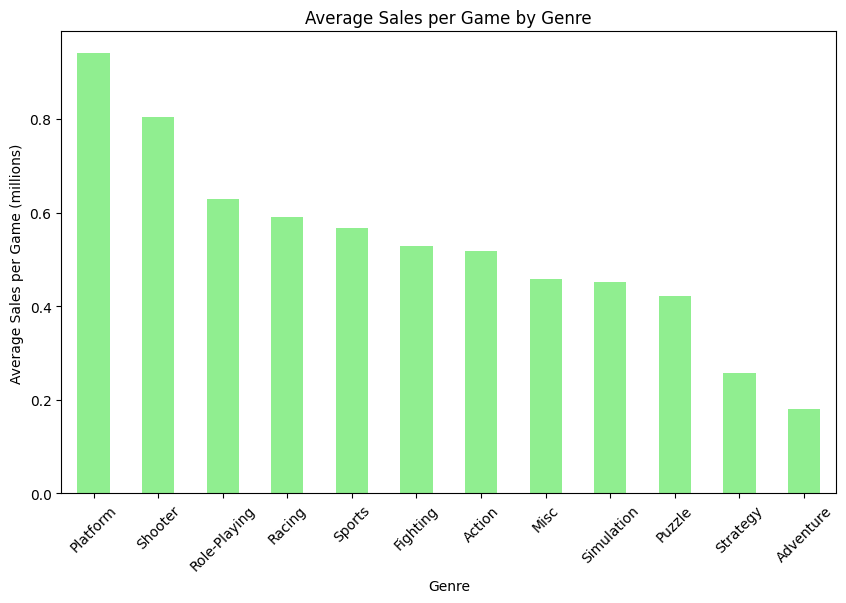

In [162]:
genre_avg_sales = games_df.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print(genre_avg_sales)
plt.figure(figsize=(10,6))
genre_avg_sales.plot(kind='bar', color='lightgreen')

plt.xlabel('Genre')
plt.ylabel('Average Sales per Game (millions)')
plt.title('Average Sales per Game by Genre')
plt.xticks(rotation=45)
plt.show()


Ahora en cuanto a las ventas promedio por juego por genero podemos observar que ahora el genero que lidera es el de los juegos de plataforma como mario bros que llegan a casi un millon de dolares de ventas en promedio por juego y despues los de shooter como Call of Duty que llegan .8 millones de dolares en ventas en promedio. Podemos observar que aunque los juegos del genero de Accion son los que lideran en el grafico de ventas totales, al momento de observar el grafico de ventas promedio por juego por genero, el genero de accion baja hasta el lugar numero 7 de los 12 generos que se pueden observar por lo que el que haya un numero de ventas totales tan alto puede ser por que es el genero mas popular para crear un juego. Los 3 generos mas bajos en ventas totales siguen siendo los 3 generos mas bajos en ventas promedio por juego por genero (aventura, estrategia y puzzle).

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
Excelente análisis . El uso de gráficos de barras permite una comprensión rápida de los géneros más lucrativos, destacando que los juegos de acción dominan las ventas totales con más de 1700 millones de dólares, mientras que géneros como estrategia, aventura y puzzle generan mucho menos. Es interesante cómo identificaste que aunque los juegos de acción lideran en ventas totales, su promedio por juego es más bajo que el de géneros como plataformas o shooters. Esto indica que, aunque el género de acción sea más popular en número de títulos, otros géneros generan más ingresos por juego individual.

La comparación entre ventas totales y ventas promedio es una observación valiosa para entender mejor el mercado y las preferencias de los jugadores. Mantén este enfoque en futuras visualizaciones, ya que te permite desglosar la información de manera detallada y ofrecer insights útiles sobre la industria de videojuegos. ¡Gran trabajo, sigue así! 📊🎮👍
</div>


In [163]:
top_5_platforms_na = games_df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_5_platforms_eu = games_df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_5_platforms_jp = games_df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Top 5 plataformas en NA:\n", top_5_platforms_na)
print("Top 5 plataformas en EU:\n", top_5_platforms_eu)
print("Top 5 plataformas en JP:\n", top_5_platforms_jp)


Top 5 plataformas en NA:
 platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64
Top 5 plataformas en EU:
 platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
PS      212.39
Name: eu_sales, dtype: float64
Top 5 plataformas en JP:
 platform
DS      175.02
PS      139.78
PS2     137.54
SNES    116.55
3DS     100.62
Name: jp_sales, dtype: float64


In [164]:
total_sales_na = games_df['na_sales'].sum()
total_sales_eu = games_df['eu_sales'].sum()
total_sales_jp = games_df['jp_sales'].sum()

top_5_platforms_na_market_share = top_5_platforms_na / total_sales_na * 100
top_5_platforms_eu_market_share = top_5_platforms_eu / total_sales_eu * 100
top_5_platforms_jp_market_share = top_5_platforms_jp / total_sales_jp * 100


print("Cuotas de mercado en NA:\n", top_5_platforms_na_market_share)
print("Cuotas de mercado en EU:\n", top_5_platforms_eu_market_share)
print("Cuotas de mercado en JP:\n", top_5_platforms_jp_market_share)


Cuotas de mercado en NA:
 platform
X360    13.722238
PS2     13.196604
Wii     11.214533
PS3      8.986230
DS       8.760037
Name: na_sales, dtype: float64
Cuotas de mercado en EU:
 platform
PS2     13.861432
PS3     13.635568
X360    11.181491
Wii     10.764769
PS       8.850763
Name: eu_sales, dtype: float64
Cuotas de mercado en JP:
 platform
DS      13.560714
PS      10.830286
PS2     10.656728
SNES     9.030404
3DS      7.796132
Name: jp_sales, dtype: float64


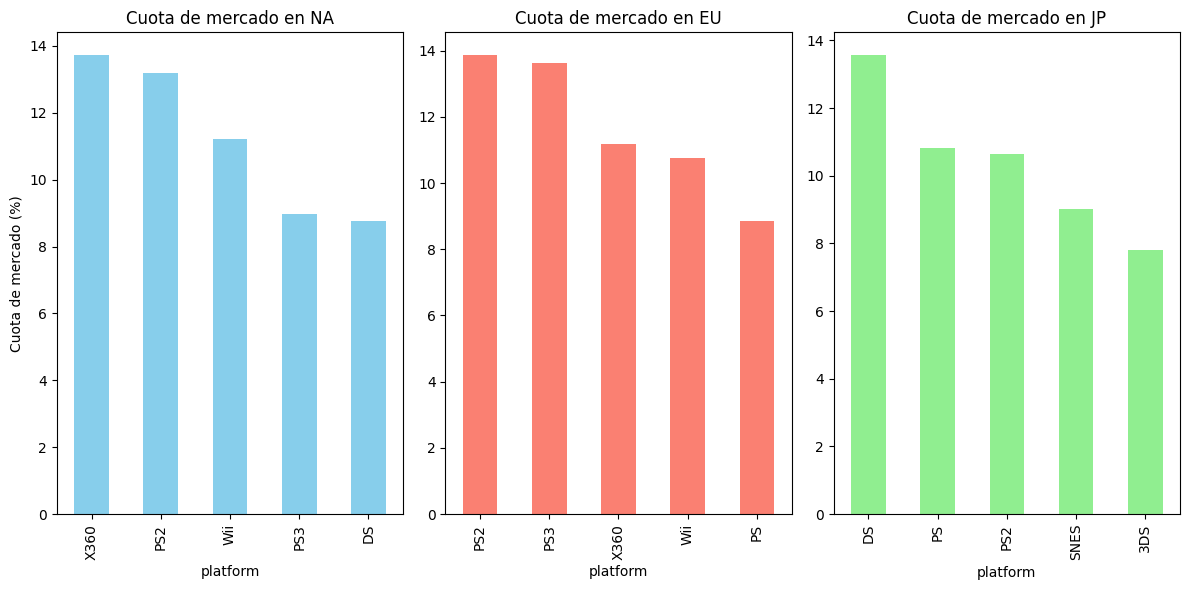

In [165]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
top_5_platforms_na_market_share.plot(kind='bar', color='skyblue')
plt.title('Cuota de mercado en NA')
plt.ylabel('Cuota de mercado (%)')

plt.subplot(1, 3, 2)
top_5_platforms_eu_market_share.plot(kind='bar', color='salmon')
plt.title('Cuota de mercado en EU')

plt.subplot(1, 3, 3)
top_5_platforms_jp_market_share.plot(kind='bar', color='lightgreen')
plt.title('Cuota de mercado en JP')

plt.tight_layout()
plt.show()


Podemos observar las diferencias entre los mercados de Japon, Norteamerica y Europa e identificar que plataformas son las que lideran en cada uno. En Norteamerica lidera X360 con un 13% en cuanto a su cuota de mercado, en Europa lidera PS2 con un 13% en cuanto a su cuota de mercado y en Japon lidera DS con un 13% en cuanto a su cuota de mercado.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
Excelente trabajo segmentando las ventas por plataforma en diferentes regiones como Norteamérica, Europa y Japón. Identificar las cinco principales plataformas en cada mercado y luego calcular sus cuotas de mercado te permite comprender mejor cómo varía el comportamiento de los consumidores según la región. La visualización en gráficos de barras es clara y efectiva para resaltar las diferencias entre las cuotas de mercado en cada región.
Este enfoque te da una visión clara de cómo adaptarse a diferentes mercados y es un análisis valioso para la toma de decisiones estratégicas. ¡Continúa con este nivel de detalle y visualización, vas por buen camino! 🌍🎮📊
</div>


In [166]:
top_5_genres_na = games_df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top_5_genres_eu = games_df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_5_genres_jp = games_df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Top 5 géneros en NA:\n", top_5_genres_na)
print("Top 5 géneros en EU:\n", top_5_genres_eu)
print("Top 5 géneros en JP:\n", top_5_genres_jp)


Top 5 géneros en NA:
 genre
Action      863.17
Sports      671.20
Shooter     584.83
Platform    444.44
Misc        399.57
Name: na_sales, dtype: float64
Top 5 géneros en EU:
 genre
Action     510.99
Sports     371.33
Shooter    314.52
Racing     234.49
Misc       210.60
Name: eu_sales, dtype: float64
Top 5 géneros en JP:
 genre
Role-Playing    353.39
Action          160.14
Sports          134.93
Platform        130.71
Misc            107.02
Name: jp_sales, dtype: float64


In [167]:
total_sales_na = games_df['na_sales'].sum()
total_sales_eu = games_df['eu_sales'].sum()
total_sales_jp = games_df['jp_sales'].sum()

top_5_genres_na_market_share = top_5_genres_na / total_sales_na * 100
top_5_genres_eu_market_share = top_5_genres_eu / total_sales_eu * 100
top_5_genres_jp_market_share = top_5_genres_jp / total_sales_jp * 100

print("Cuotas de mercado en NA:\n", top_5_genres_na_market_share)
print("Cuotas de mercado en EU:\n", top_5_genres_eu_market_share)
print("Cuotas de mercado en JP:\n", top_5_genres_jp_market_share)


Cuotas de mercado en NA:
 genre
Action      19.882204
Sports      15.460379
Shooter     13.470938
Platform    10.237203
Misc         9.203671
Name: na_sales, dtype: float64
Cuotas de mercado en EU:
 genre
Action     21.294089
Sports     15.474147
Shooter    13.106748
Racing      9.771720
Misc        8.776170
Name: eu_sales, dtype: float64
Cuotas de mercado en JP:
 genre
Role-Playing    27.380989
Action          12.407798
Sports          10.454503
Platform        10.127534
Misc             8.292010
Name: jp_sales, dtype: float64


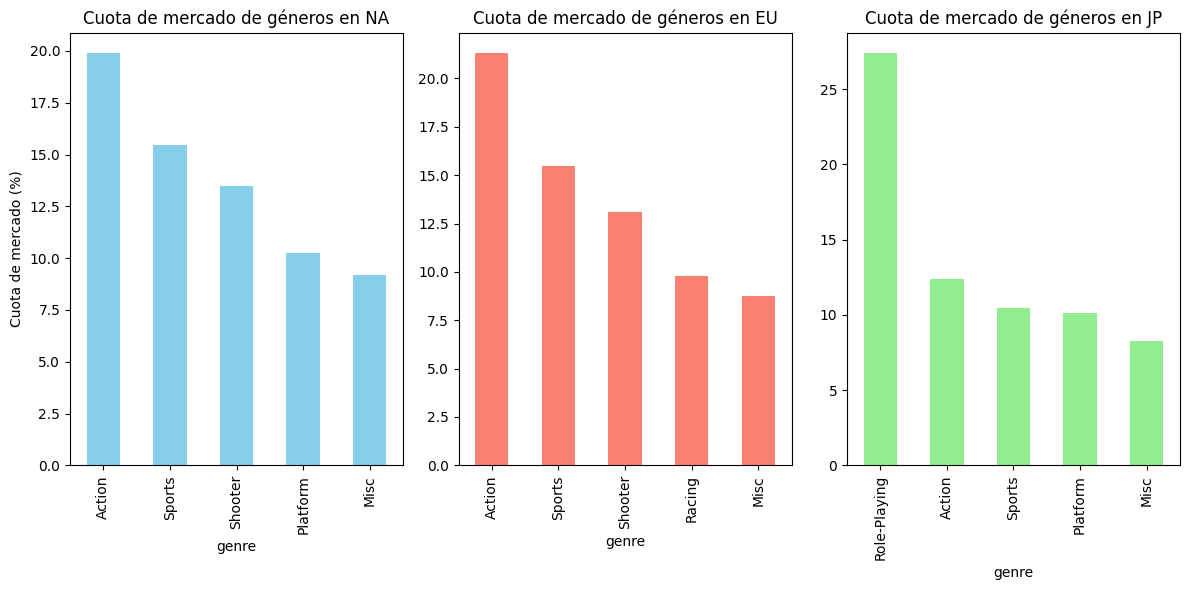

In [168]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
top_5_genres_na_market_share.plot(kind='bar', color='skyblue')
plt.title('Cuota de mercado de géneros en NA')
plt.ylabel('Cuota de mercado (%)')

plt.subplot(1, 3, 2)
top_5_genres_eu_market_share.plot(kind='bar', color='salmon')
plt.title('Cuota de mercado de géneros en EU')

plt.subplot(1, 3, 3)
top_5_genres_jp_market_share.plot(kind='bar', color='lightgreen')
plt.title('Cuota de mercado de géneros en JP')

plt.tight_layout()
plt.show()


Podemos observar las diferencias entre los mercados de Japon, Norteamerica y Europa e identificar que generos son los que lideran en cada uno. En Norteamerica lidera accion con un 19% en cuanto a su cuota de mercado, en Europa tambien lidera accion con un 22% en cuanto a su cuota de mercado y en Japon lidera el genero de role-playing con un 27% en cuanto a su cuota de mercado.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Tu análisis de las cuotas de mercado por género en Norteamérica, Europa y Japón es muy claro y preciso. Al identificar los géneros más populares en cada región y representar sus cuotas de mercado con gráficos de barras, ofreces una visión clara de las preferencias regionales. Este tipo de análisis es valioso para entender las tendencias del mercado y adaptar estrategias según las regiones.
El uso de comparaciones visuales entre regiones hace que las diferencias sean fáciles de interpretar. Sigue con este enfoque analítico y visual, ya que proporciona insights importantes sobre las variaciones en el mercado global. ¡Gran trabajo, sigue adelante! 🎮🌍📊
</div>


In [169]:
esrb_na_sales = games_df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
esrb_eu_sales = games_df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
esrb_jp_sales = games_df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

print("Ventas por ESRB en NA:\n", esrb_na_sales)
print("Ventas por ESRB en EU:\n", esrb_eu_sales)
print("Ventas por ESRB en JP:\n", esrb_jp_sales)


Ventas por ESRB en NA:
 rating
E            1274.24
no rating    1225.84
T             747.60
M             742.89
E10+          345.50
K-A             2.56
EC              1.53
AO              1.26
RP              0.00
Name: na_sales, dtype: float64
Ventas por ESRB en EU:
 rating
E            703.87
no rating    609.65
M            480.00
T            421.79
E10+         183.35
AO             0.61
K-A            0.27
EC             0.11
RP             0.03
Name: eu_sales, dtype: float64
Ventas por ESRB en JP:
 rating
no rating    836.74
E            197.96
T            150.70
M             63.58
E10+          40.20
K-A            1.46
AO             0.00
EC             0.00
RP             0.00
Name: jp_sales, dtype: float64


In [170]:
total_sales_na = games_df['na_sales'].sum()
total_sales_eu = games_df['eu_sales'].sum()
total_sales_jp = games_df['jp_sales'].sum()


In [171]:
esrb_market_share_na = esrb_na_sales / total_sales_na * 100
esrb_market_share_eu = esrb_eu_sales / total_sales_eu * 100
esrb_market_share_jp = esrb_jp_sales / total_sales_jp * 100

print("Cuotas de mercado en NA:\n", esrb_market_share_na)
print("Cuotas de mercado en EU:\n", esrb_market_share_eu)
print("Cuotas de mercado en JP:\n", esrb_market_share_jp)


Cuotas de mercado en NA:
 rating
E            29.350765
no rating    28.235923
T            17.220172
M            17.111682
E10+          7.958226
K-A           0.058967
EC            0.035242
AO            0.029023
RP            0.000000
Name: na_sales, dtype: float64
Cuotas de mercado en EU:
 rating
E            29.331828
no rating    25.405471
M            20.002667
T            17.576927
E10+          7.640602
AO            0.025420
K-A           0.011252
EC            0.004584
RP            0.001250
Name: eu_sales, dtype: float64
Cuotas de mercado en JP:
 rating
no rating    64.831401
E            15.338127
T            11.676378
M             4.926238
E10+          3.114734
K-A           0.113122
AO            0.000000
EC            0.000000
RP            0.000000
Name: jp_sales, dtype: float64


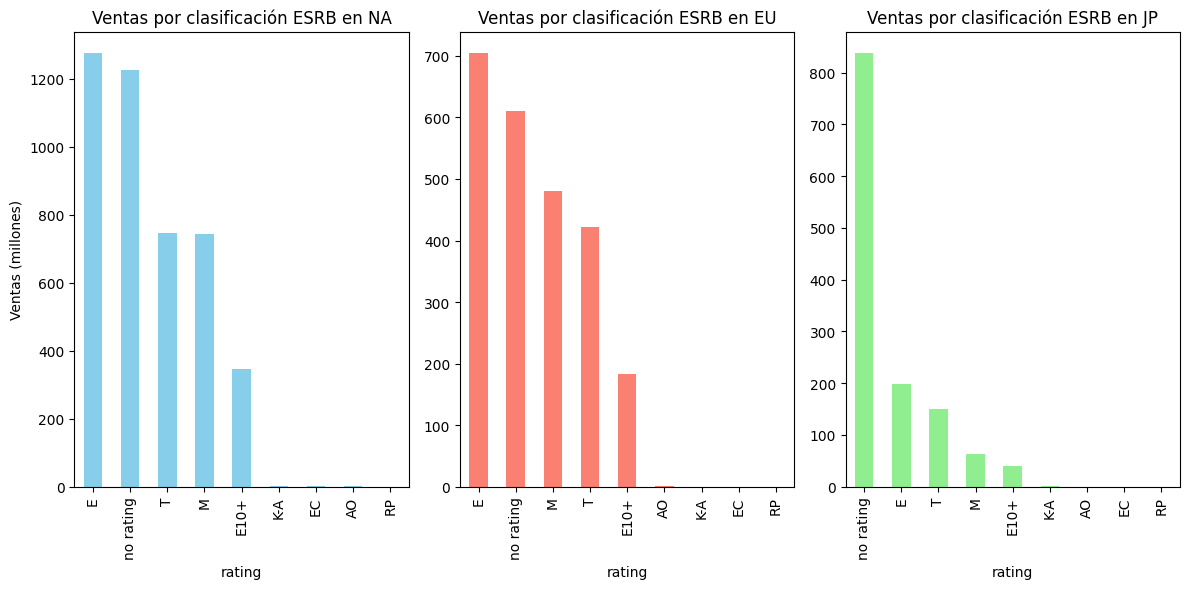

In [172]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
esrb_na_sales.plot(kind='bar', color='skyblue')
plt.title('Ventas por clasificación ESRB en NA')
plt.ylabel('Ventas (millones)')

plt.subplot(1, 3, 2)
esrb_eu_sales.plot(kind='bar', color='salmon')
plt.title('Ventas por clasificación ESRB en EU')

plt.subplot(1, 3, 3)
esrb_jp_sales.plot(kind='bar', color='lightgreen')
plt.title('Ventas por clasificación ESRB en JP')

plt.tight_layout()
plt.show()


Podemos observar las diferencias entre los mercados de Japon, Norteamerica y Europa e identificar que clasificaciones ESRB son las que lideran en cada uno en la venta de videojuegos. En Norteamerica y Europa lideran los juegos con clasificacion E con 1300 y 700 millones en ventas respectivamente mientras que en Japon lideran los juegos que no tienen rating con un poco mas de 800 millones en ventas y despues los juegos con clasificacion E con solo 200 millones en ventas, una gran diferencia comparado con NA y EU.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
Excelente trabajo al analizar las ventas por clasificación ESRB en Norteamérica, Europa y Japón. Has capturado de manera clara las diferencias en las preferencias de clasificación en cada región. Esta comparación resalta las variaciones culturales y de mercado en diferentes zonas.

El uso de gráficos para visualizar estas diferencias facilita la interpretación y añade un valor visual importante a tu análisis. Sigue utilizando este enfoque para destacar los insights clave y comunicar datos de forma efectiva. ¡Muy buen trabajo, sigue así! 🎮🌍📈
</div>


# formulacion de hipotesis
Establecemos el nivel de significancia alfa en 0.05

Ahora formulamos las hipotesis

Hipótesis Nula 1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Hipótesis Alternativa 1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

In [175]:

xbox_scores = games_df[games_df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = games_df[games_df['platform'] == 'PC']['user_score'].dropna()

alpha = .05
results = st.ttest_ind(xbox_scores, pc_scores)

print('valor p:', results.pvalue)
if (results.pvalue<alpha):
    print("Rechazamos la hipótesis nula 1")
else:
    print("No podemos rechazar la hipótesis nula 1")



valor p: 3.039516169044684e-05
Rechazamos la hipótesis nula 1


En cuanto a la hipotesis nula 1 y la Hipotesis alternativa 1 tras haber realizado la prueba T en los datos de user_score para xbox one y pc podemos rechazar la hipotesis nula 1 que dice que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas. 

En realidad podemos decir que las calificaciones promedio de los usuarios para las plataformas Xbox One  PC son diferentes.

Hipótesis Nula 2: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son las mismas.

Hipótesis Alternativa 2: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [176]:

action_scores = games_df[games_df['genre'] == 'Action']['user_score'].dropna()
sports_scores = games_df[games_df['genre'] == 'Sports']['user_score'].dropna()

results_genre = st.ttest_ind(action_scores, sports_scores)


print('valor p:', results_genre.pvalue)
if (results_genre.pvalue<alpha):
    print("Rechazamos la hipótesis nula 2")
else:
    print("No podemos rechazar la hipótesis nula 2")





valor p: 0.12279663539579658
No podemos rechazar la hipótesis nula 2


Ahora en cuanto a la hipotesis nula 2 y la hipotesis alternativa 2 realizamos la misma prueba pero ahora con los datos de user_score para los generos de accion y deportes y en este caso no podemos rechazar la hipotesis nula 2 que dice que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son las mismas, por lo que rechazamos la hipotesis alternativa 2 y las calificaciones para ambos generos si seran las mismas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Excelente trabajo en la formulación y prueba de hipótesis! Has implementado correctamente la prueba T para comparar las calificaciones promedio de los usuarios entre diferentes plataformas y géneros. El enfoque paso a paso que seguiste para establecer las hipótesis, ejecutar las pruebas y analizar los resultados demuestra una sólida comprensión de los conceptos estadísticos clave.
Es positivo ver que utilizas un nivel de significancia apropiado (α = 0.05) y que interpretas claramente los valores p. La manera en que concluyes la diferencia en las calificaciones promedio de Xbox One y PC, y cómo comparas los géneros, es precisa y fundamentada.
¡Sigue utilizando estos métodos para respaldar tus conclusiones con datos sólidos y análisis estadístico, estás haciendo un gran trabajo! 💡📊
</div>


# Conclusion General

En este proyecto, analizamos datos de ventas de videojuegos, considerando factores como plataformas, géneros, reseñas y clasificaciones de ESRB. Tras corregir los datos, identificamos las plataformas y géneros más exitosos y cómo varían las ventas por región. Observamos que las reseñas de usuarios y críticos influyen en las ventas, especialmente en plataformas populares.

Primero tomamos los datos y nos aseguramos de corregir los errores que posriamos encontrar, como valores ausentes, duplicados, etc. Despues con el analisis exploratorio logramos identificar los generos y plataformas que suelen ser mas exitosos e identificamos aquellos que no suelen serlo.

En cuanto a las reseñas, logramos identificar que la correlacion entre las reseñas de criticos tiene un impacto directo en las ventas ya que se encontro una fuerte correlacion positiva, entre mas altas reseñas de criticos mas ventas habran y creimos que seria lo mismo para las reseñas de los usuarios pero no fue el caso, identificamos que aunque si habia na correlacion positiva, esta era mucho menor.

En general, este análisis ayuda a identificar tendencias y maximizar oportunidades en el mercado de videojuegos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Excelente cierre del proyecto! Has sintetizado muy bien los resultados obtenidos a lo largo del análisis, destacando los puntos más importantes como la influencia de las reseñas de críticos y usuarios en las ventas de videojuegos. La estructura de la conclusión es clara y lógica, proporcionando un resumen efectivo de cómo abordaste el análisis de las plataformas, géneros y ventas regionales. 
Es positivo que hayas señalado diferencias clave entre las reseñas de críticos y usuarios y su impacto en las ventas, lo cual refleja un análisis profundo de los datos. También,  la identificación de tendencias para maximizar oportunidades en el mercado demuestra una aplicación práctica del análisis.
¡Continúa desarrollando este enfoque analítico en futuros proyectos, vas por muy buen camino! 🚀🎮📊
</div>


# Comentario Final del Revisor

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
    
¡Felicidades! Tu proyecto está **aprobado**. Has hecho un trabajo excepcional al abordar el análisis de datos de ventas de videojuegos, desde la limpieza de los datos hasta la interpretación de los resultados de las hipótesis. Aquí algunos puntos clave:

#### Puntos Positivos:
- **Limpieza y transformación de datos:** Manejaste de manera correcta los valores faltantes, duplicados y conversiones de tipos de datos.
- **Análisis exploratorio:** Has utilizado una combinación de gráficos y estadísticas descriptivas para ofrecer un panorama claro de las ventas por plataforma y género.
- **Hipótesis:** Tus pruebas de hipótesis fueron bien formuladas y ejecutadas, y lograste extraer conclusiones significativas sobre las calificaciones de los usuarios y su impacto en las ventas.

#### Áreas para seguir explorando:
- **Modelos predictivos:** Podrías intentar crear modelos que predigan las ventas futuras con base en las reseñas o los géneros más populares.
- **Análisis de series temporales:** Dado que trabajaste con datos que varían con el tiempo, podrías profundizar en técnicas de análisis de series temporales para identificar patrones o estacionalidad.

¡Sigue adelante! Tu habilidad para realizar análisis detallados y sacar conclusiones útiles está creciendo rápidamente. ¡Sigue así! 💪🎉🎮
</div>
